# TAHAP 4 - HYPERPARAMETER TUNING: Mencari Parameter Terbaik RF & XGBoost

Notebook ini mencari kombinasi hyperparameter terbaik untuk **Random Forest** dan **XGBoost**
menggunakan **RandomizedSearchCV** (lebih cepat dari GridSearchCV).

**Alur:**
1. Load data & build fitur (sama persis dengan 02_train_supervised.ipynb)
2. Tuning RF dengan RandomizedSearchCV (CV 5-fold, optimasi PR-AUC)
3. Tuning XGBoost dengan RandomizedSearchCV (CV 5-fold, optimasi PR-AUC)
4. Simpan model terbaik:  models/supervised_rf.pkl & models/supervised_xgb.pkl
5. Visualisasi perbandingan performa: Default vs Tuned


## Import & Konfigurasi

In [1]:
import os
import sys
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, average_precision_score,
    f1_score, precision_score, recall_score
)

# Coba import XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[!] XGBoost belum terpasang. Jalankan: pip install xgboost")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#    Path setup (sama persis dengan notebook 02)   
current_dir = os.path.abspath('')
if os.path.basename(current_dir) == 'ml_pipeline':
    ml_path = current_dir
else:
    ml_path = os.path.join(current_dir, 'ml_pipeline')
if ml_path not in sys.path:
    sys.path.insert(0, ml_path)

from feature_engineering import load_data
from pola_b_features import build_pola_b_matrix

RF_MODEL_PATH  = os.path.join(ml_path, "models", "supervised_rf.pkl")
XGB_MODEL_PATH = os.path.join(ml_path, "models", "supervised_xgb.pkl")
SPLIT_PATH     = os.path.join(ml_path, "models", "test_split.pkl")
RANDOM_STATE   = 42
N_ITER         = 50   # jumlah kombinasi yang dicoba per model
CV_FOLDS       = 5

print(" Import & konfigurasi selesai")
print(f"     XGBoost tersedia: {XGBOOST_AVAILABLE}")
print(f"     RandomizedSearchCV: n_iter={N_ITER}, cv={CV_FOLDS}-fold")

 Import & konfigurasi selesai
     XGBoost tersedia: True
     RandomizedSearchCV: n_iter=50, cv=5-fold


## Load Data & Build Fitur Pola B

In [2]:
print("[1/5] Memuat data + membangun fitur Pola B...")

raw  = load_data()
X    = build_pola_b_matrix(raw)
y    = raw["is_fraud"].astype(int)

print(f"      {X.shape[0]:,} baris x {X.shape[1]} fitur | fraud: {int(y.sum())} ({y.mean():.1%})")

# Split stratified 70/30 — SAMA dengan notebook 02 agar test set identik
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

print(f"\n  Train: {len(X_tr):,} baris (fraud {int(y_tr.sum())} = {y_tr.mean():.1%})")
print(f"  Test:  {len(X_te):,} baris (fraud {int(y_te.sum())} = {y_te.mean():.1%})")
print(f"  Scale pos weight (XGBoost): {scale_pos_weight:.2f}")

[1/5] Memuat data + membangun fitur Pola B...


      2,116 baris x 10 fitur | fraud: 116 (5.5%)

  Train: 1,481 baris (fraud 81 = 5.5%)
  Test:  635 baris (fraud 35 = 5.5%)
  Scale pos weight (XGBoost): 17.28


## Performa Baseline (Sebelum Tuning)

Kita rekam dulu performa dengan parameter default `02_train_supervised.ipynb`
sebagai **pembanding setelah tuning**.

In [3]:
print("[2/5] Melatih model baseline untuk pembanding...")

#    Baseline RF (parameter dari 02_train_supervised)   
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_base.fit(X_tr, y_tr)
y_pred_rf_base  = rf_base.predict(X_te)
y_proba_rf_base = rf_base.predict_proba(X_te)[:, 1]

baseline_rf = {
    "Precision": precision_score(y_te, y_pred_rf_base, zero_division=0),
    "Recall":    recall_score(y_te, y_pred_rf_base, zero_division=0),
    "F1":        f1_score(y_te, y_pred_rf_base, zero_division=0),
    "PR-AUC":    average_precision_score(y_te, y_proba_rf_base),
}
print(f"  RF Baseline  → F1: {baseline_rf['F1']:.4f} | PR-AUC: {baseline_rf['PR-AUC']:.4f}")

#    Baseline XGBoost   
baseline_xgb = None
if XGBOOST_AVAILABLE:
    xgb_base = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss"
    )
    xgb_base.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    y_pred_xgb_base  = xgb_base.predict(X_te)
    y_proba_xgb_base = xgb_base.predict_proba(X_te)[:, 1]

    baseline_xgb = {
        "Precision": precision_score(y_te, y_pred_xgb_base, zero_division=0),
        "Recall":    recall_score(y_te, y_pred_xgb_base, zero_division=0),
        "F1":        f1_score(y_te, y_pred_xgb_base, zero_division=0),
        "PR-AUC":    average_precision_score(y_te, y_proba_xgb_base),
    }
    print(f"  XGB Baseline → F1: {baseline_xgb['F1']:.4f} | PR-AUC: {baseline_xgb['PR-AUC']:.4f}")
else:
    print("  XGBoost tidak tersedia - lewati baseline XGBoost")

print("\n  Baseline terekam. Lanjut ke tuning...")

[2/5] Melatih model baseline untuk pembanding...


  RF Baseline  → F1: 0.9275 | PR-AUC: 0.9826


  XGB Baseline → F1: 0.9714 | PR-AUC: 0.9918

  Baseline terekam. Lanjut ke tuning...


## Tuning Random Forest

Scoring: **PR-AUC** (cocok untuk data imbalanced fraud)

In [4]:
print("[3/5] Tuning Random Forest (RandomizedSearchCV)...")
print(f"      Mencoba {N_ITER} kombinasi x {CV_FOLDS} fold = {N_ITER*CV_FOLDS} fits")
print("      Harap tunggu...\n")

rf_param_dist = {
    "n_estimators":      randint(100, 501),
    "max_depth":         [4, 6, 8, 10, 12, 15, None],
    "min_samples_split": randint(2, 21),
    "min_samples_leaf":  randint(1, 11),
    "class_weight":      ["balanced", "balanced_subsample"],
    "max_features":      ["sqrt", "log2", 0.5, 0.6, 0.7, 0.8],
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

t0 = time.time()
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
rf_search.fit(X_tr, y_tr)
elapsed_rf = time.time() - t0

best_rf = rf_search.best_estimator_

print(f"\n  Selesai dalam {elapsed_rf:.1f} detik")
print(f"  CV PR-AUC terbaik : {rf_search.best_score_:.4f}")
print(f"\n  Parameter terbaik:")
for k, v in rf_search.best_params_.items():
    print(f"    {k:25s}: {v}")

# Evaluasi pada test set
y_pred_rf_tuned  = best_rf.predict(X_te)
y_proba_rf_tuned = best_rf.predict_proba(X_te)[:, 1]
tuned_rf = {
    "Precision": precision_score(y_te, y_pred_rf_tuned, zero_division=0),
    "Recall":    recall_score(y_te, y_pred_rf_tuned, zero_division=0),
    "F1":        f1_score(y_te, y_pred_rf_tuned, zero_division=0),
    "PR-AUC":    average_precision_score(y_te, y_proba_rf_tuned),
}
print(f"\n  Test set  F1: {tuned_rf['F1']:.4f} | PR-AUC: {tuned_rf['PR-AUC']:.4f}")
delta_f1    = tuned_rf['F1']    - baseline_rf['F1']
delta_prauc = tuned_rf['PR-AUC'] - baseline_rf['PR-AUC']
print(f"  Delta vs baseline  F1: {delta_f1:+.4f} | PR-AUC: {delta_prauc:+.4f}")

[3/5] Tuning Random Forest (RandomizedSearchCV)...
      Mencoba 50 kombinasi x 5 fold = 250 fits
      Harap tunggu...

Fitting 5 folds for each of 50 candidates, totalling 250 fits



  Selesai dalam 80.0 detik
  CV PR-AUC terbaik : 0.9798

  Parameter terbaik:
    class_weight             : balanced
    max_depth                : None
    max_features             : 0.5
    min_samples_leaf         : 4
    min_samples_split        : 8
    n_estimators             : 407



  Test set  F1: 0.8831 | PR-AUC: 0.9811
  Delta vs baseline  F1: -0.0444 | PR-AUC: -0.0015


## Tuning XGBoost


In [5]:
if not XGBOOST_AVAILABLE:
    print("[!] XGBoost tidak tersedia — lewati sel ini")
    best_xgb = None
    tuned_xgb = None
else:
    print("[3.5/5] Tuning XGBoost (RandomizedSearchCV)...")
    print(f"        Mencoba {N_ITER} kombinasi x {CV_FOLDS} fold = {N_ITER*CV_FOLDS} fits")
    print("        Harap tunggu...\n")

    xgb_param_dist = {
        "n_estimators":      randint(100, 501),
        "max_depth":         randint(3, 11),
        "learning_rate":     uniform(0.01, 0.29),
        "subsample":         uniform(0.5, 0.5),
        "colsample_bytree":  uniform(0.5, 0.5),
        "reg_alpha":         uniform(0, 2),
        "reg_lambda":        uniform(0.5, 2.5),
        "scale_pos_weight":  [1.0, scale_pos_weight],
    }

    t0 = time.time()
    xgb_search = RandomizedSearchCV(
        xgb.XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=-1,
            eval_metric="logloss", verbosity=0
        ),
        param_distributions=xgb_param_dist,
        n_iter=N_ITER,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    xgb_search.fit(X_tr, y_tr)
    elapsed_xgb = time.time() - t0

    best_xgb = xgb_search.best_estimator_

    print(f"\n  Selesai dalam {elapsed_xgb:.1f} detik")
    print(f"  CV PR-AUC terbaik : {xgb_search.best_score_:.4f}")
    print(f"\n  Parameter terbaik:")
    for k, v in xgb_search.best_params_.items():
        print(f"    {k:25s}: {v:.4f}" if isinstance(v, float) else f"    {k:25s}: {v}")

    y_pred_xgb_tuned  = best_xgb.predict(X_te)
    y_proba_xgb_tuned = best_xgb.predict_proba(X_te)[:, 1]
    tuned_xgb = {
        "Precision": precision_score(y_te, y_pred_xgb_tuned, zero_division=0),
        "Recall":    recall_score(y_te, y_pred_xgb_tuned, zero_division=0),
        "F1":        f1_score(y_te, y_pred_xgb_tuned, zero_division=0),
        "PR-AUC":    average_precision_score(y_te, y_proba_xgb_tuned),
    }
    delta_f1    = tuned_xgb['F1']    - baseline_xgb['F1']
    delta_prauc = tuned_xgb['PR-AUC'] - baseline_xgb['PR-AUC']
    print(f"\n  Test set  F1: {tuned_xgb['F1']:.4f} | PR-AUC: {tuned_xgb['PR-AUC']:.4f}")
    print(f" Delta vs baseline   F1: {delta_f1:+.4f} | PR-AUC: {delta_prauc:+.4f}")

[3.5/5] Tuning XGBoost (RandomizedSearchCV)...
        Mencoba 50 kombinasi x 5 fold = 250 fits
        Harap tunggu...

Fitting 5 folds for each of 50 candidates, totalling 250 fits



  Selesai dalam 9.3 detik
  CV PR-AUC terbaik : 0.9889

  Parameter terbaik:
    colsample_bytree         : 0.5610
    learning_rate            : 0.1536
    max_depth                : 9
    n_estimators             : 134
    reg_alpha                : 1.8186
    reg_lambda               : 1.1469
    scale_pos_weight         : 17.2840
    subsample                : 0.8777

  Test set  F1: 0.9714 | PR-AUC: 0.9920
 Delta vs baseline   F1: +0.0000 | PR-AUC: +0.0002


## Simpan Model Terbaik

Model hasil tuning menggantikan model default dari 02_train_supervised.ipynb.
Test split **tidak diubah** agar 03_evaluate.ipyn tetap konsisten.

In [6]:
print("[4/5] Menyimpan model terbaik hasil tuning...")

os.makedirs(os.path.dirname(RF_MODEL_PATH), exist_ok=True)

# Simpan RF terbaik
joblib.dump(best_rf, RF_MODEL_PATH)
print(f"  ✓ RF Tuned   → {RF_MODEL_PATH}")

# Simpan XGBoost terbaik (jika ada)
if best_xgb is not None:
    joblib.dump(best_xgb, XGB_MODEL_PATH)
    print(f"  ✓ XGB Tuned  → {XGB_MODEL_PATH}")
else:
    print("  - XGB Tuned  → LEWAT (tidak tersedia)")

# Simpan test split (SAMA dengan notebook 02, tidak berubah)
joblib.dump({"X_test": X_te, "y_test": y_te}, SPLIT_PATH)
print(f"  ✓ Test split → {SPLIT_PATH}")

print("\nSemua model tersimpan! Jalankan 03_evaluate.ipynb untuk melihat hasil lengkap.")

[4/5] Menyimpan model terbaik hasil tuning...


  ✓ RF Tuned   → C:\Users\gavin\Documents\KULIAH\SEMS 6\Capstone\FraudGuard-POS-AI-Based-Cashier-Monitoring-System-for-UMKM\ml_pipeline\models\supervised_rf.pkl
  ✓ XGB Tuned  → C:\Users\gavin\Documents\KULIAH\SEMS 6\Capstone\FraudGuard-POS-AI-Based-Cashier-Monitoring-System-for-UMKM\ml_pipeline\models\supervised_xgb.pkl
  ✓ Test split → C:\Users\gavin\Documents\KULIAH\SEMS 6\Capstone\FraudGuard-POS-AI-Based-Cashier-Monitoring-System-for-UMKM\ml_pipeline\models\test_split.pkl

Semua model tersimpan! Jalankan 03_evaluate.ipynb untuk melihat hasil lengkap.


## Visualisasi: Default vs Tuned

[5/5] Membuat visualisasi perbandingan...


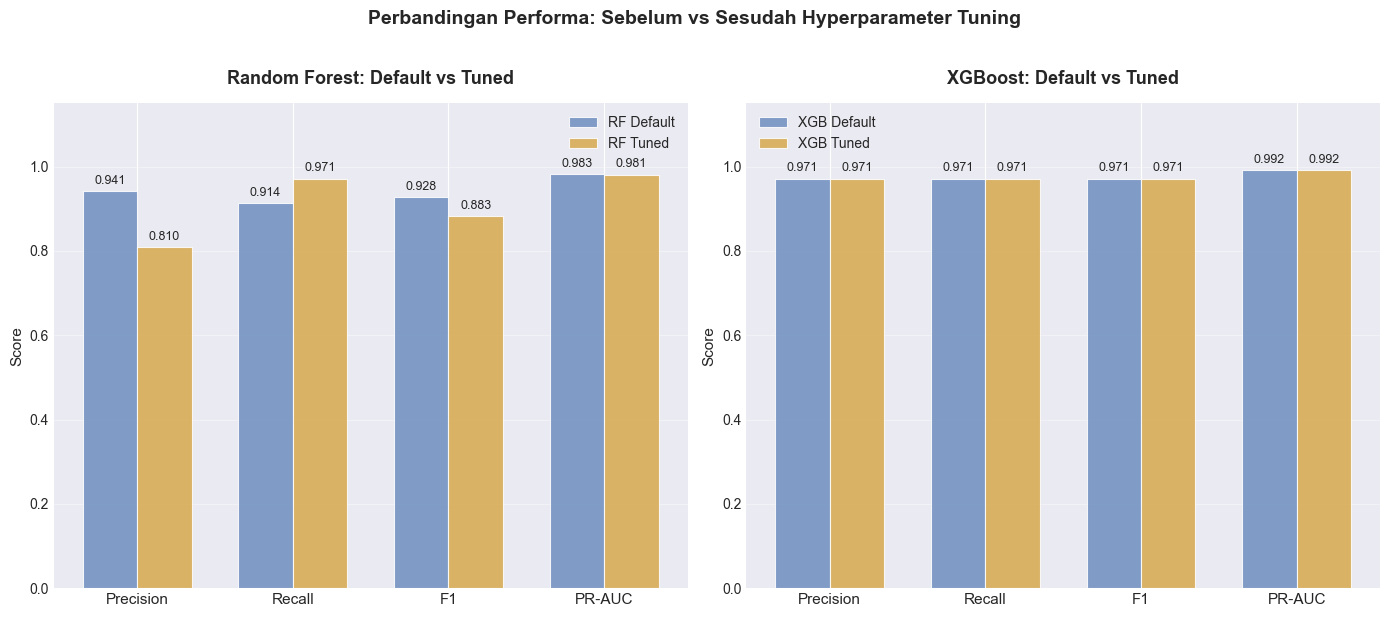

 RINGKASAN HASIL TUNING
Model              Precision   Recall       F1   PR-AUC
RF Default            0.9412   0.9143   0.9275   0.9826
RF Tuned              0.8095   0.9714   0.8831   0.9811
-----------------------------------------------------------------
XGB Default           0.9714   0.9714   0.9714   0.9918
XGB Tuned             0.9714   0.9714   0.9714   0.9920

Lanjut ke 03_evaluate.ipynb untuk perbandingan penuh dengan IF Baseline.


In [7]:
print("[5/5] Membuat visualisasi perbandingan...")

metrics = ["Precision", "Recall", "F1", "PR-AUC"]

#    Siapkan data   
rf_labels  = ["RF Default", "RF Tuned"]
rf_vals    = [[baseline_rf[m]   for m in metrics],
              [tuned_rf[m]      for m in metrics]]

has_xgb = (baseline_xgb is not None and tuned_xgb is not None)
if has_xgb:
    xgb_labels = ["XGB Default", "XGB Tuned"]
    xgb_vals   = [[baseline_xgb[m] for m in metrics],
                  [tuned_xgb[m]    for m in metrics]]

#    Plot   
n_cols   = 2 if has_xgb else 1
fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), sharey=False)
if n_cols == 1:
    axes = [axes]

COLORS = ["#6c8ebf", "#d6a84e"]

def plot_comparison(ax, labels, vals, title):
    x      = np.arange(len(metrics))
    width  = 0.35
    bars0  = ax.bar(x - width/2, vals[0], width, label=labels[0],
                    color=COLORS[0], alpha=0.85, edgecolor='white', linewidth=0.8)
    bars1  = ax.bar(x + width/2, vals[1], width, label=labels[1],
                    color=COLORS[1], alpha=0.85, edgecolor='white', linewidth=0.8)

    # Nilai di atas bar
    for bar in list(bars0) + list(bars1):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(axis='y', alpha=0.35)

plot_comparison(axes[0], rf_labels, rf_vals, "Random Forest: Default vs Tuned")
if has_xgb:
    plot_comparison(axes[1], xgb_labels, xgb_vals, "XGBoost: Default vs Tuned")

fig.suptitle("Perbandingan Performa: Sebelum vs Sesudah Hyperparameter Tuning",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Tabel ringkasan 
print(" RINGKASAN HASIL TUNING")
print(f"{'Model':<18} {'Precision':>9} {'Recall':>8} {'F1':>8} {'PR-AUC':>8}")
print(f"{'RF Default':<18} {baseline_rf['Precision']:>9.4f} {baseline_rf['Recall']:>8.4f} {baseline_rf['F1']:>8.4f} {baseline_rf['PR-AUC']:>8.4f}")
print(f"{'RF Tuned':<18} {tuned_rf['Precision']:>9.4f} {tuned_rf['Recall']:>8.4f} {tuned_rf['F1']:>8.4f} {tuned_rf['PR-AUC']:>8.4f}")
if has_xgb:
    print("-"*65)
    print(f"{'XGB Default':<18} {baseline_xgb['Precision']:>9.4f} {baseline_xgb['Recall']:>8.4f} {baseline_xgb['F1']:>8.4f} {baseline_xgb['PR-AUC']:>8.4f}")
    print(f"{'XGB Tuned':<18} {tuned_xgb['Precision']:>9.4f} {tuned_xgb['Recall']:>8.4f} {tuned_xgb['F1']:>8.4f} {tuned_xgb['PR-AUC']:>8.4f}")
print("\nLanjut ke 03_evaluate.ipynb untuk perbandingan penuh dengan IF Baseline.")